In [2]:
import pandas as pd
import numpy as np

In [3]:
physical = pd.read_csv("Tamil_physical_parameters.csv")
chemical = pd.read_csv("Tamil_chemical_parameters.csv")
biological = pd.read_csv("Tamil_biological_parameters.csv")

In [4]:
physical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8229 entries, 0 to 8228
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SlNo                           8229 non-null   int64  
 1   Station                        8229 non-null   object 
 2   Agency                         8229 non-null   object 
 3   State LGD Code                 8229 non-null   int64  
 4   State                          8229 non-null   object 
 5   District LGD Code              8229 non-null   int64  
 6   District                       8229 non-null   object 
 7   Tehsil                         8229 non-null   object 
 8   Block                          8229 non-null   object 
 9   Village                        8229 non-null   object 
 10  River                          8229 non-null   object 
 11  Basin                          8229 non-null   object 
 12  Tributary                      8229 non-null   o

In [5]:
physical.columns

Index(['SlNo', 'Station', 'Agency', 'State LGD Code', 'State',
       'District LGD Code', 'District', 'Tehsil', 'Block', 'Village', 'River',
       'Basin', 'Tributary', 'Subtributary', 'SubSubtributary', 'Local River',
       'Latitude', 'Longitude', 'Data Acquisition Time',
       'Electric Conductivity (μS/cm)', 'Colour', 'Odour', 'Turbidity (NTU)',
       'Temperature (ºC)', 'Total Solids (mg/L)'],
      dtype='object')

In [6]:
physical.isnull().sum()

SlNo                                0
Station                             0
Agency                              0
State LGD Code                      0
State                               0
District LGD Code                   0
District                            0
Tehsil                              0
Block                               0
Village                             0
River                               0
Basin                               0
Tributary                           0
Subtributary                        0
SubSubtributary                     0
Local River                         0
Latitude                            0
Longitude                           0
Data Acquisition Time               0
Electric Conductivity (μS/cm)      85
Colour                           2934
Odour                             639
Turbidity (NTU)                  8114
Temperature (ºC)                 3417
Total Solids (mg/L)              4581
dtype: int64

**We will find common columns to merge our data sets.
Before that we want them to have get them in a python understandable form, for that we use set and list, and .intersection() is used to find common name in both**

In [7]:
common_columns = list(set(physical.columns.intersection(chemical.columns).intersection(biological.columns)))

In [8]:
common_columns

['State',
 'SubSubtributary',
 'Local River',
 'Agency',
 'District LGD Code',
 'River',
 'Tehsil',
 'Tributary',
 'Station',
 'Longitude',
 'Village',
 'State LGD Code',
 'SlNo',
 'Subtributary',
 'Block',
 'Data Acquisition Time',
 'Basin',
 'District',
 'Latitude']

**Before merging we have to remove duplicates.
This is done to prevent any complications while merging.
We will be using Station and Data Acquisition Time because it tells us the location and time from where sample is been precureed, So if they are same it means data set has duplicate data present in it.**

In [9]:
merge_keys = ["Station","Data Acquisition Time"]

physical.duplicated(subset=merge_keys).sum()
chemical.duplicated(subset=merge_keys).sum()
biological.duplicated(subset=merge_keys).sum()

np.int64(0)

**Finding whether common columns have same data, and whether any of the column has null data.
We use .duplicated(subset=).sum()/if their is no subset then it will find for whole and will tell how many are duplicates.
And .isnull().sum() will tell if their are any missing values.**

In [10]:
physical[merge_keys].isnull().sum()
chemical[merge_keys].isnull().sum()
biological[merge_keys].isnull().sum()

Station                  0
Data Acquisition Time    0
dtype: int64

**we use '&' to check how many are common and '-' to check which one in left are different.
'zip()' it combine multiple columns together**

In [11]:
physical_keys = set(zip(physical["Station"], physical["Data Acquisition Time"]))
chemical_keys = set(zip(chemical["Station"], chemical["Data Acquisition Time"]))
biological_keys = set(zip(biological["Station"], biological["Data Acquisition Time"]))

In [12]:
physical_keys - chemical_keys
chemical_keys - physical_keys

physical_keys - biological_keys
biological_keys - physical_keys

chemical_keys - biological_keys
biological_keys - chemical_keys


set()

**.drop() is used to remove common columns from everyfile except one, if you write a number/index then it will drop the index number row, but if inside you write column="name of column" then it will delete that column.
And pd.merge merge only 2 dataframes**

In [13]:
repeated_columns = list(set(common_columns)-set(merge_keys))

In [14]:
chemical_2 = chemical.drop(columns=repeated_columns)
biological_2 = biological.drop(columns=repeated_columns)

In [15]:
merged_1 = pd.merge(physical,chemical_2,how='inner',on = merge_keys)
merged_2 = pd.merge(merged_1,biological_2,how='inner',on = merge_keys)

In [16]:
merged_2.head()

,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,...,Nickel (mg/L),Lead (mg/L),Zinc (mg/L),Sodium Adsorption Ratio (%),Nitrate (mg/L),Copper (mg/L),Biochemical Oxygen Demand (mg/L),Chemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL),Total Coliform (MPN/100mL)
0,359,AMBARAMPALAYAM,CWC,33,Tamil Nadu,569,Coimbatore,POLLACHI,ANAIMALAI,Ambarampalayam,...,NaN,NaN,NaN,0.760150,NaN,NaN,2.0,NaN,NaN,NaN
1,360,AMBARAMPALAYAM,CWC,33,Tamil Nadu,569,Coimbatore,POLLACHI,ANAIMALAI,Ambarampalayam,...,NaN,NaN,NaN,0.422742,NaN,NaN,1.0,NaN,NaN,NaN
2,361,AMBARAMPALAYAM,CWC,33,Tamil Nadu,569,Coimbatore,POLLACHI,ANAIMALAI,Ambarampalayam,...,NaN,NaN,NaN,0.730146,NaN,NaN,0.8,NaN,NaN,NaN
3,362,AMBARAMPALAYAM,CWC,33,Tamil Nadu,569,Coimbatore,POLLACHI,ANAIMALAI,Ambarampalayam,...,NaN,NaN,NaN,0.412672,NaN,NaN,0.9,NaN,NaN,NaN
4,363,AMBARAMPALAYAM,CWC,33,Tamil Nadu,569,Coimbatore,POLLACHI,ANAIMALAI,Ambarampalayam,...,NaN,NaN,NaN,0.332026,NaN,NaN,0.8,NaN,NaN,NaN


In [17]:
merged_2.duplicated().sum()

np.int64(0)

In [18]:
merged_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2815 entries, 0 to 2814
Data columns (total 62 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SlNo                                2815 non-null   int64  
 1   Station                             2815 non-null   object 
 2   Agency                              2815 non-null   object 
 3   State LGD Code                      2815 non-null   int64  
 4   State                               2815 non-null   object 
 5   District LGD Code                   2815 non-null   int64  
 6   District                            2815 non-null   object 
 7   Tehsil                              2815 non-null   object 
 8   Block                               2815 non-null   object 
 9   Village                             2815 non-null   object 
 10  River                               2815 non-null   object 
 11  Basin                               2815 no

In [19]:
merged_2.describe()

,SlNo,State LGD Code,District LGD Code,Latitude,Longitude,Electric Conductivity (μS/cm),Turbidity (NTU),Temperature (ºC),Total Solids (mg/L),Amonia N (mgN/L),...,Nickel (mg/L),Lead (mg/L),Zinc (mg/L),Sodium Adsorption Ratio (%),Nitrate (mg/L),Copper (mg/L),Biochemical Oxygen Demand (mg/L),Chemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL),Total Coliform (MPN/100mL)
count,2815.000000,2815.0,2815.000000,2815.000000,2815.000000,2797.000000,36.000000,2763.000000,1.0,1381.000000,...,210.000000,216.000000,254.000000,2730.000000,0.0,243.000000,2800.000000,0.0,11.000000,12.000000
mean,4225.046892,33.0,584.095915,11.180881,77.969977,598.323554,76.368056,26.187948,0.0,0.263239,...,7.226039,3.149567,26.313913,1.868486,NaN,5.324580,1.982308,NaN,1336.363636,1408.333333
std,2386.012783,0.0,26.256824,0.977565,0.863159,1012.023789,140.635281,2.562042,NaN,4.033357,...,13.923450,8.770621,85.065868,3.053442,NaN,7.360193,2.894299,NaN,463.190516,487.028715
min,359.000000,33.0,569.000000,8.302222,76.891111,11.760000,0.000000,9.200000,0.0,0.000000,...,0.000000,0.000000,0.004000,0.089537,NaN,0.000000,0.100000,NaN,500.000000,0.000000
25%,1895.500000,33.0,573.000000,10.903611,77.510000,196.000000,6.782500,24.500000,0.0,0.040200,...,1.622500,0.890000,3.000000,0.584623,NaN,1.640000,0.800000,NaN,1250.000000,1600.000000
50%,4202.000000,33.0,577.000000,11.080000,77.835000,373.000000,17.000000,26.000000,0.0,0.064000,...,4.175000,1.560000,9.000000,1.075126,NaN,2.980000,1.360000,NaN,1600.000000,1600.000000
75%,6187.500000,33.0,590.000000,11.572778,78.138333,579.000000,90.925000,28.000000,0.0,0.155000,...,8.715000,2.970250,21.925000,2.014205,NaN,5.000000,2.190000,NaN,1600.000000,1600.000000
max,8229.000000,33.0,731.000000,12.913889,79.947222,12000.000000,768.400000,39.400000,0.0,141.000000,...,126.300000,122.010000,1200.000000,29.380136,NaN,58.040000,39.300000,NaN,1600.000000,1600.000000


In [20]:
merged_2.groupby("River").size()

River
Bharathapuzha           172
Cauvery                1755
Duplicate-Palar          90
Duplicate-Ponnaiyar     336
Duplicate-Vaigai        251
Duplicate-Vellar         24
Tambraparani              1
Thambraparani           185
Thambraparni              1
dtype: int64

In [21]:
merged_2.groupby("River")[["Turbidity (NTU)","Total Solids (mg/L)","Total Dissolved Solids (mg/L)","Dissolved oxygen (mg/L)","Total Alkalinity (mg/L as CaCO3)","Total Hardness (mgCaCO3/L)","Biochemical Oxygen Demand (mg/L)","Chemical Oxygen Demand (mg/L)","Total Coliform (MPN/100mL)"]].mean()

,Turbidity (NTU),Total Solids (mg/L),Total Dissolved Solids (mg/L),Dissolved oxygen (mg/L),Total Alkalinity (mg/L as CaCO3),Total Hardness (mgCaCO3/L),Biochemical Oxygen Demand (mg/L),Chemical Oxygen Demand (mg/L),Total Coliform (MPN/100mL)
River,,,,,,,,,
Bharathapuzha,NaN,NaN,116.582857,6.758165,89.973607,91.056304,1.187384,NaN,NaN
Cauvery,99.743333,0.0,277.113182,6.853716,133.988708,159.698254,1.629445,NaN,0.000000
Duplicate-Palar,50.810909,NaN,437.962500,5.739091,164.417252,166.182067,1.710856,NaN,NaN
Duplicate-Ponnaiyar,6.607500,NaN,627.376582,5.522169,273.138026,285.090632,5.236401,NaN,NaN
Duplicate-Vaigai,NaN,NaN,88.826087,6.981984,91.096953,97.362816,1.418765,NaN,1536.363636
Duplicate-Vellar,122.840000,NaN,189.975000,5.873333,114.227675,116.409128,1.651833,NaN,NaN
Tambraparani,NaN,NaN,1585.000000,NaN,234.614760,555.533300,0.790000,NaN,NaN
Thambraparani,NaN,NaN,109.761765,5.800811,57.844794,66.560784,1.257892,NaN,NaN
Thambraparni,NaN,NaN,116.000000,NaN,34.016390,32.416668,0.800000,NaN,NaN


In [22]:
merged_2["Chemical Oxygen Demand (mg/L)"].isnull().sum()

np.int64(2815)

In [23]:
merged_2[
    [
        "Turbidity (NTU)",
        "Total Solids (mg/L)",
        "Total Dissolved Solids (mg/L)",
        "Dissolved oxygen (mg/L)",
        "Total Alkalinity (mg/L as CaCO3)",
        "Total Hardness (mgCaCO3/L)",
        "Biochemical Oxygen Demand (mg/L)",
        "Chemical Oxygen Demand (mg/L)",
        "Total Coliform (MPN/100mL)"
    ]
].isnull().sum()

Turbidity (NTU)                     2779
Total Solids (mg/L)                 2814
Total Dissolved Solids (mg/L)       1997
Dissolved oxygen (mg/L)              366
Total Alkalinity (mg/L as CaCO3)      52
Total Hardness (mgCaCO3/L)            36
Biochemical Oxygen Demand (mg/L)      15
Chemical Oxygen Demand (mg/L)       2815
Total Coliform (MPN/100mL)          2803
dtype: int64

*After grouping by when we are selecting columns they should be a list, but when we are providing several names then they it is take it as tuple, so we use extra "[]" inside to make it a list*

**| Parameter                           | Why it matters                                                                                                                                                                    |
| ----------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Turbidity**                       | Measures how cloudy the water is due to suspended particles. High turbidity reduces sunlight penetration, affects aquatic plants, and can indicate erosion, runoff, or pollution. |
| **Total Solids (TS)**               | The total amount of dissolved and suspended matter in water. High values may affect taste, industrial use, and indicate pollution.                                                |
| **Total Dissolved Solids (TDS)**    | Measures dissolved salts and minerals. High TDS can make water unsuitable for drinking or irrigation and may indicate salinity or industrial discharge.                           |
| **Dissolved Oxygen (DO)**           | One of the most important indicators of river health. Aquatic organisms need oxygen to survive. Low DO often signals organic pollution or stagnant water.                         |
| **Total Alkalinity**                | Measures the water's ability to neutralize acids (its buffering capacity). It helps stabilize pH and protects aquatic life from sudden pH changes.                                |
| **Total Hardness**                  | Indicates calcium and magnesium concentrations. Important for drinking water, industrial processes, and aquatic ecosystems. Very hard water can cause scaling.                    |
| **Biochemical Oxygen Demand (BOD)** | Measures how much oxygen microorganisms need to decompose organic matter. High BOD usually means a high level of biodegradable pollution (e.g., sewage).                          |
| **Chemical Oxygen Demand (COD)**    | Measures the oxygen required to chemically oxidize both biodegradable and non-biodegradable pollutants. High COD often indicates industrial or chemical pollution.                |
| **Total Coliform**                  | Indicates possible contamination from human or animal waste. High coliform counts suggest a risk of pathogens and unsafe water for drinking or recreation.                        |
**

**⭐ Tier 1 (Critical)
Dissolved Oxygen (DO),
Biochemical Oxygen Demand (BOD),
Chemical Oxygen Demand (COD),
Total Coliform.

These directly reflect the ecological and pollution status of the river.

⭐ Tier 2 (Very Important)
Turbidity,
Total Dissolved Solids (TDS).

These affect water clarity, usability, and can indicate sediment or dissolved pollutant loads.

⭐ Tier 3 (Supporting Indicators)
Total Solids,
Total Alkalinity,
Total Hardness.

These provide context about the chemical characteristics of the water and are important for drinking water assessment, treatment, and long-term monitoring.**

**| Parameter        |                                               Common Reference (IS 10500/WHO) |
| ---------------- | ----------------------------------------------------------------------------: |
| Turbidity        |                                      ≤1 NTU (acceptable), 5 NTU (permissible) |
| Total Solids     |                                                                   No standard |
| TDS              | 500 mg/L (acceptable), 2000 mg/L (permissible in absence of alternate source) |
| Total Alkalinity |                                 200 mg/L (acceptable), 600 mg/L (permissible) |
| Total Hardness   |                                 200 mg/L (acceptable), 600 mg/L (permissible) |
| COD              |                                                No BIS drinking water standard |
| DO               |                                             Not applicable for drinking water |
| BOD              |                                             Not applicable for drinking water |
| Total Coliform   |                                                                  0 MPN/100 mL |
**

**| Parameter                        |                                     IS 2296:1982 |     CPCB Designated Best Use |
| -------------------------------- | -----------------------------------------------: | ---------------------------: |
| Turbidity (NTU)                  |                                    Not specified |                Not specified |
| Total Solids (mg/L)              |                                    Not specified |                Not specified |
| Total Dissolved Solids (mg/L)    | ≤500 (Class A), ≤1500 (Class C), ≤2100 (Class E) | Same values where applicable |
| Dissolved Oxygen (mg/L)          |                       A: ≥6, B: ≥5, C: ≥4, D: ≥4 |                         Same |
| Total Alkalinity (mg/L as CaCO₃) |                                    Not specified |                Not specified |
| Total Hardness (mg/L as CaCO₃)   |                              ≤300 (Class A only) |                         Same |
| Biochemical Oxygen Demand (mg/L) |                              A: ≤2, B: ≤3, C: ≤3 |                         Same |
| Chemical Oxygen Demand (mg/L)    |                                    Not specified |                Not specified |
| Total Coliform (MPN/100 mL)      |                        A: ≤50, B: ≤500, C: ≤5000 |                         Same |
**

**Now we want to check the correlation for validating tha data, that's why we are using .corr()**

**We will check correlation for organic pollution, physical water quality, and mineral content.**

In [24]:
organic = [
    "Dissolved oxygen (mg/L)",
    "Biochemical Oxygen Demand (mg/L)",
    "Chemical Oxygen Demand (mg/L)",
    "Total Coliform (MPN/100mL)"
]

merged_2[organic].corr()

,Dissolved oxygen (mg/L),Biochemical Oxygen Demand (mg/L),Chemical Oxygen Demand (mg/L),Total Coliform (MPN/100mL)
Dissolved oxygen (mg/L),1.000000,-0.499687,NaN,-0.643800
Biochemical Oxygen Demand (mg/L),-0.499687,1.000000,NaN,0.343445
Chemical Oxygen Demand (mg/L),NaN,NaN,NaN,NaN
Total Coliform (MPN/100mL),-0.643800,0.343445,NaN,1.000000


**Conclusion 1
DO and BOD show a moderate inverse relationship.
This agrees with the expected environmental behavior that increased organic pollution is associated with lower dissolved oxygen.

Conclusion 2
DO and Total Coliform have a moderately strong negative correlation (-0.64).
This suggests that areas with higher bacterial contamination generally have lower dissolved oxygen.

Conclusion 3
BOD and Total Coliform show only a weak positive relationship (0.34).
This indicates that bacterial contamination alone does not explain all variation in BOD. Other factors likely contribute to the organic pollution levels observed.**

In [25]:
merged_2.groupby("River")[organic].corr()

Dissolved oxygen (mg/L)  \
River                                                                           
Bharathapuzha       Dissolved oxygen (mg/L)                          1.000000   
                    Biochemical Oxygen Demand (mg/L)                -0.124553   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   
Cauvery             Dissolved oxygen (mg/L)                          1.000000   
                    Biochemical Oxygen Demand (mg/L)                -0.137482   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   
Duplicate-Palar     Dissolved oxygen (mg/L)                          1.000000   
                    Biochemical Oxygen Demand (mg/L)                -0.120909   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   
Duplicate-Ponnaiyar Dissolved oxygen (mg/L)                          1.000000   
                    Biochemical Oxygen Demand (mg/L)                -0.702685   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   
Duplicate-Vaigai    Dissolved oxygen (mg/L)                          1.000000   
                    Biochemical Oxygen Demand (mg/L)                -0.074909   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                      -0.643800   
Duplicate-Vellar    Dissolved oxygen (mg/L)                          1.000000   
                    Biochemical Oxygen Demand (mg/L)                -0.517846   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   
Tambraparani        Dissolved oxygen (mg/L)                               NaN   
                    Biochemical Oxygen Demand (mg/L)                      NaN   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   
Thambraparani       Dissolved oxygen (mg/L)                          1.000000   
                    Biochemical Oxygen Demand (mg/L)                -0.060354   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   
Thambraparni        Dissolved oxygen (mg/L)                               NaN   
                    Biochemical Oxygen Demand (mg/L)                      NaN   
                    Chemical Oxygen Demand (mg/L)                         NaN   
                    Total Coliform (MPN/100mL)                            NaN   

                                                      Biochemical Oxygen Demand (mg/L)  \
River                                                                                    
Bharathapuzha       Dissolved oxygen (mg/L)                                  -0.124553   
                    Biochemical Oxygen Demand (mg/L)                          1.000000   
                    Chemical Oxygen Demand (mg/L)                                  NaN   
                    Total Coliform (MPN/100mL)                                     NaN   
Cauvery             Dissolved oxygen (mg/L)                                  -0.137482   
                    Biochemical Oxygen Demand (mg/L)                          1.000000   
                    Chemical Oxygen Demand (mg/L)                                  NaN   
                    Total Coliform (MPN/100mL)                                     NaN   
Duplicate-Palar     Dissolved oxygen (mg/L)                                

In [26]:
chemical = [
    "Total Dissolved Solids (mg/L)",
    "Total Hardness (mgCaCO3/L)",
    "Total Alkalinity (mg/L as CaCO3)"
]

merged_2[chemical].corr()

,Total Dissolved Solids (mg/L),Total Hardness (mgCaCO3/L),Total Alkalinity (mg/L as CaCO3)
Total Dissolved Solids (mg/L),1.000000,0.794661,0.787313
Total Hardness (mgCaCO3/L),0.794661,1.000000,0.844544
Total Alkalinity (mg/L as CaCO3),0.787313,0.844544,1.000000


**Total Dissolved Solids (TDS) and Total Hardness exhibited a strong positive correlation (r = 0.795), indicating that water samples with higher dissolved mineral content generally also had greater hardness. This is consistent with the contribution of calcium and magnesium ions to both parameters.
TDS and Total Alkalinity showed a strong positive correlation (r = 0.787), suggesting that increased concentrations of dissolved ions are associated with higher alkalinity and improved buffering capacity of the water.
The strongest relationship was observed between Total Hardness and Total Alkalinity (r = 0.845), indicating that these parameters are closely linked, likely due to the presence of carbonate and bicarbonate minerals in natural waters.
Overall, the strong positive correlations among TDS, hardness, and alkalinity suggest that the hydrochemistry of the sampled waters is primarily influenced by dissolved mineral constituents, reflecting expected natural geochemical processes.**

In [27]:
merged_2.groupby("River")[chemical].corr()

Total Dissolved Solids (mg/L)  \
River                                                                                 
Bharathapuzha       Total Dissolved Solids (mg/L)                          1.000000   
                    Total Hardness (mgCaCO3/L)                             0.985971   
                    Total Alkalinity (mg/L as CaCO3)                       0.977759   
Cauvery             Total Dissolved Solids (mg/L)                          1.000000   
                    Total Hardness (mgCaCO3/L)                             0.689943   
                    Total Alkalinity (mg/L as CaCO3)                       0.742560   
Duplicate-Palar     Total Dissolved Solids (mg/L)                          1.000000   
                    Total Hardness (mgCaCO3/L)                             0.951513   
                    Total Alkalinity (mg/L as CaCO3)                       0.858557   
Duplicate-Ponnaiyar Total Dissolved Solids (mg/L)                          1.000000   
                    Total Hardness (mgCaCO3/L)                             0.748929   
                    Total Alkalinity (mg/L as CaCO3)                       0.677088   
Duplicate-Vaigai    Total Dissolved Solids (mg/L)                          1.000000   
                    Total Hardness (mgCaCO3/L)                             0.975423   
                    Total Alkalinity (mg/L as CaCO3)                       0.969676   
Duplicate-Vellar    Total Dissolved Solids (mg/L)                          1.000000   
                    Total Hardness (mgCaCO3/L)                             0.940838   
                    Total Alkalinity (mg/L as CaCO3)                       0.768244   
Tambraparani        Total Dissolved Solids (mg/L)                               NaN   
                    Total Hardness (mgCaCO3/L)                                  NaN   
                    Total Alkalinity (mg/L as CaCO3)                            NaN   
Thambraparani       Total Dissolved Solids (mg/L)                          1.000000   
                    Total Hardness (mgCaCO3/L)                             0.974944   
                    Total Alkalinity (mg/L as CaCO3)                       0.940298   
Thambraparni        Total Dissolved Solids (mg/L)                               NaN   
                    Total Hardness (mgCaCO3/L)                                  NaN   
                    Total Alkalinity (mg/L as CaCO3)                            NaN   

                                                      Total Hardness (mgCaCO3/L)  \
River                                                                              
Bharathapuzha       Total Dissolved Solids (mg/L)                       0.985971   
                    Total Hardness (mgCaCO3/L)                          1.000000   
                    Total Alkalinity (mg/L as CaCO3)                    0.959988   
Cauvery             Total Dissolved Solids (mg/L)                       0.689943   
                    Total Hardness (mgCaCO3/L)                          1.000000   
                    Total Alkalinity (mg/L as CaCO3)                    0.826575   
Duplicate-Palar     Total Dissolved Solids (mg/L)                       0.951513   
                    Total Hardness (mgCaCO3/L)                          1.000000   
                    Total Alkalinity (mg/L as CaCO3)                    0.839340   
Duplicate-Ponnaiyar Total Dissolved Solids (mg/L)                       0.748929   
                    Total Hardness (mgCaCO3/L)                          1.000000   
                    Total Alkalinity (mg/L as CaCO3)                    0.725426   
Duplicate-Vaigai    Total Dissolved Solids (mg/L)                       0.975423   
                    Total Hardness (mgCaCO3/L)                          1.000000   
                    Total Alkalinity (mg/L as CaCO3)                    0.974318   
Duplicate-Vellar    Total Dissolved Solids (mg/L)                       0.940838   
                  

In [28]:
physical = [
    "Turbidity (NTU)",
    "Total Solids (mg/L)",
    "Total Dissolved Solids (mg/L)"
]

merged_2[physical].corr()

,Turbidity (NTU),Total Solids (mg/L),Total Dissolved Solids (mg/L)
Turbidity (NTU),1.000000,NaN,-0.257038
Total Solids (mg/L),NaN,NaN,NaN
Total Dissolved Solids (mg/L),-0.257038,NaN,1.000000


**Turbidity and Total Dissolved Solids (TDS) exhibited a weak negative correlation (r = -0.257), indicating that the concentration of dissolved solids has little influence on water turbidity in the study area. This is consistent with the fact that turbidity is primarily affected by suspended particles, whereas TDS represents dissolved minerals and salts.**

In [29]:
merged_2.groupby("River")[physical].corr()

Turbidity (NTU)  \
River                                                                
Bharathapuzha       Turbidity (NTU)                            NaN   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)              NaN   
Cauvery             Turbidity (NTU)                       1.000000   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)        -0.031832   
Duplicate-Palar     Turbidity (NTU)                       1.000000   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)        -0.484926   
Duplicate-Ponnaiyar Turbidity (NTU)                       1.000000   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)        -0.132109   
Duplicate-Vaigai    Turbidity (NTU)                            NaN   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)              NaN   
Duplicate-Vellar    Turbidity (NTU)                       1.000000   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)         0.425268   
Tambraparani        Turbidity (NTU)                            NaN   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)              NaN   
Thambraparani       Turbidity (NTU)                            NaN   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)              NaN   
Thambraparni        Turbidity (NTU)                            NaN   
                    Total Solids (mg/L)                        NaN   
                    Total Dissolved Solids (mg/L)              NaN   

                                                   Total Solids (mg/L)  \
River                                                                    
Bharathapuzha       Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Cauvery             Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Duplicate-Palar     Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Duplicate-Ponnaiyar Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Duplicate-Vaigai    Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Duplicate-Vellar    Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Tambraparani        Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Thambraparani       Turbidity (NTU)                                NaN   
                    Total Solids (mg/L)                            NaN   
                    Total Dissolved Solids (mg/L)                  NaN   
Thambraparni        Turbidity (NTU)                                NaN   
                    To

In [30]:
import matplotlib.pyplot as plt

**.hist(bins=20) .hist makes histogram, and bins=x, this x is interval used to group values**

In [31]:
merged_2[["Biochemical Oxygen Demand (mg/L)",
    "Chemical Oxygen Demand (mg/L)"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2815 entries, 0 to 2814
Data columns (total 2 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Biochemical Oxygen Demand (mg/L)  2800 non-null   float64
 1   Chemical Oxygen Demand (mg/L)     0 non-null      float64
dtypes: float64(2)
memory usage: 44.1 KB


In [32]:
merged_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2815 entries, 0 to 2814
Data columns (total 62 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SlNo                                2815 non-null   int64  
 1   Station                             2815 non-null   object 
 2   Agency                              2815 non-null   object 
 3   State LGD Code                      2815 non-null   int64  
 4   State                               2815 non-null   object 
 5   District LGD Code                   2815 non-null   int64  
 6   District                            2815 non-null   object 
 7   Tehsil                              2815 non-null   object 
 8   Block                               2815 non-null   object 
 9   Village                             2815 non-null   object 
 10  River                               2815 non-null   object 
 11  Basin                               2815 no

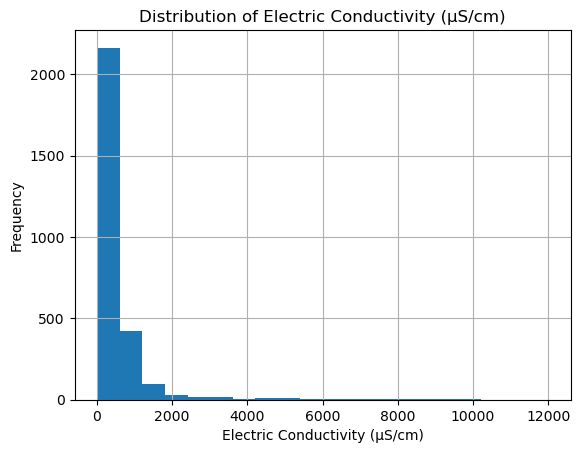

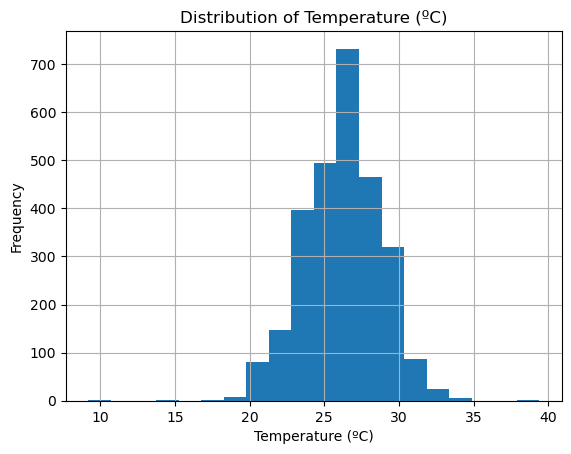

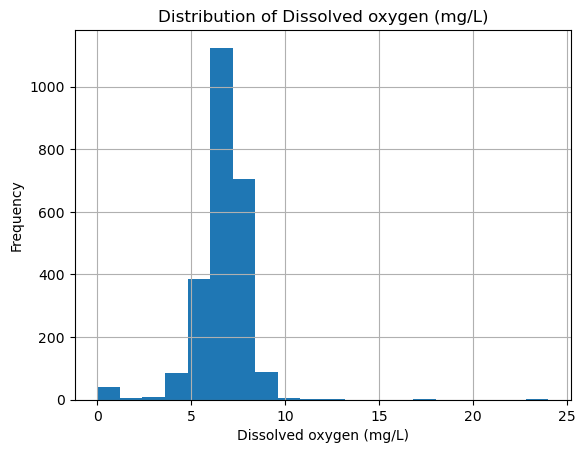

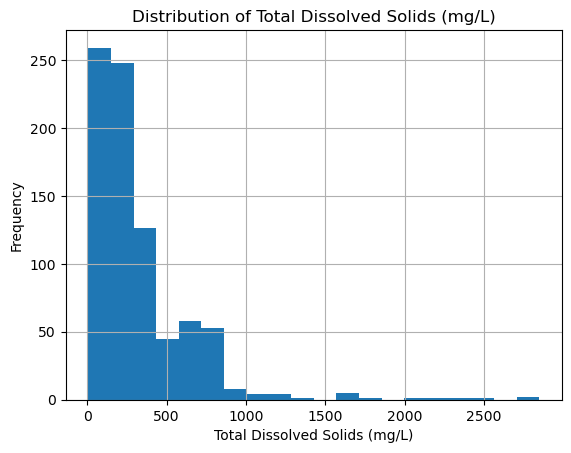

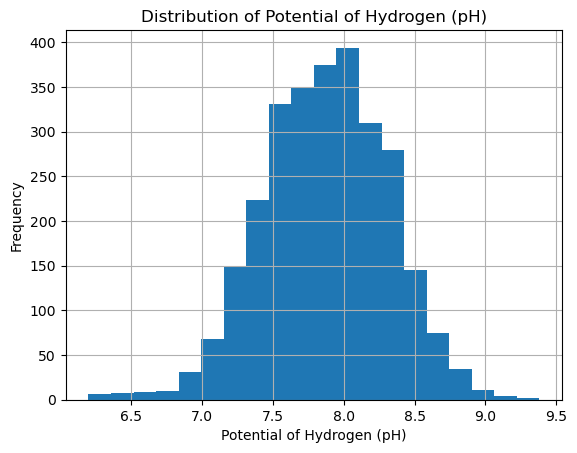

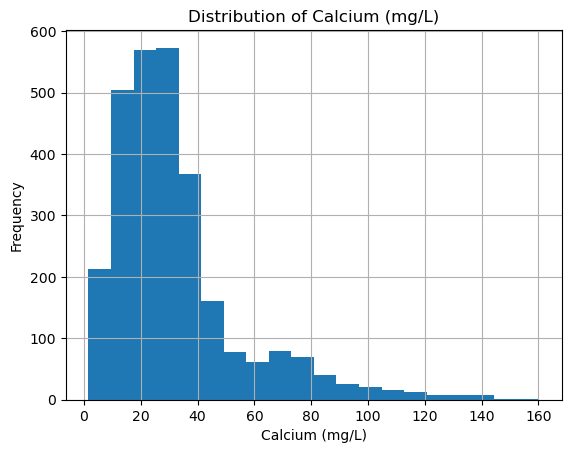

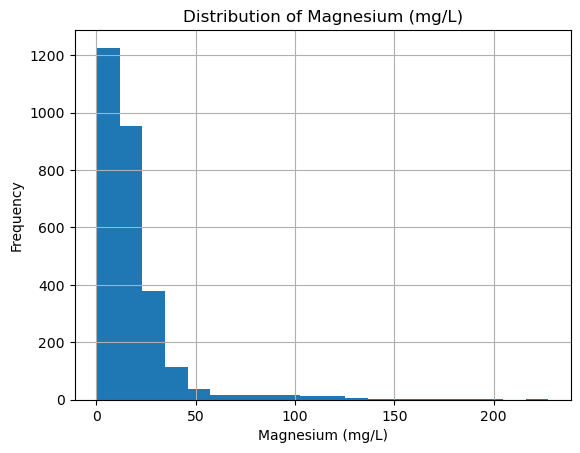

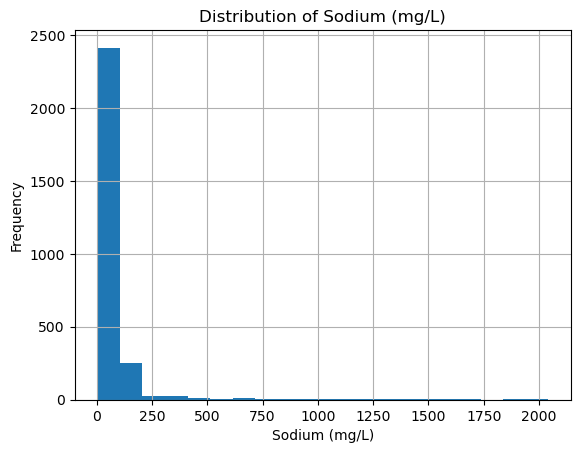

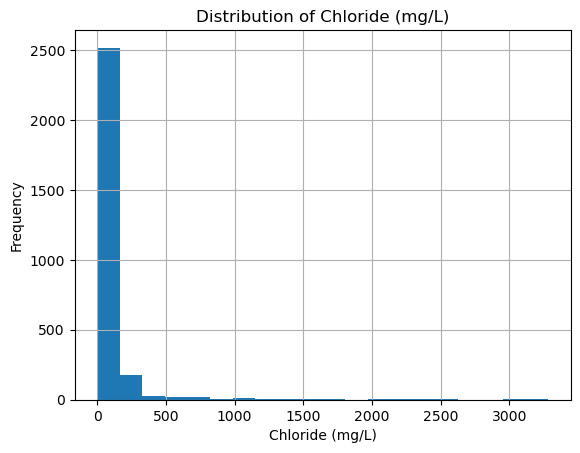

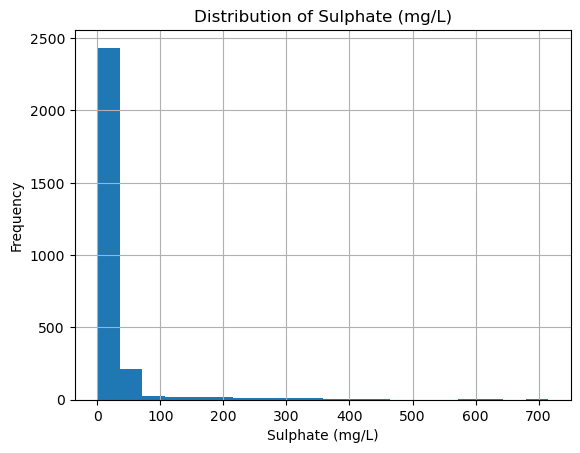

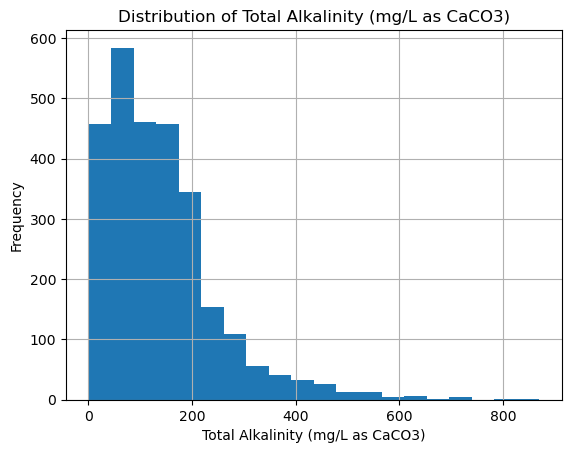

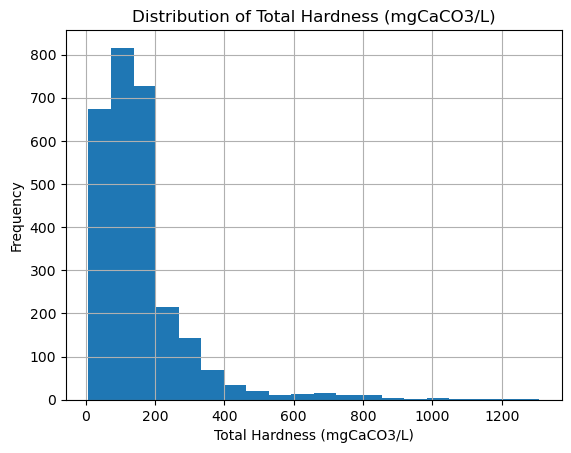

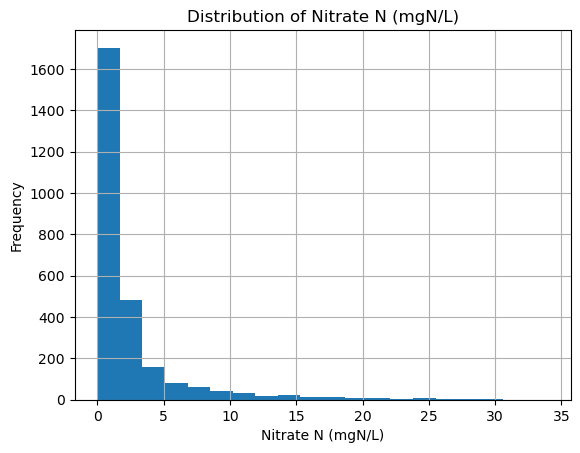

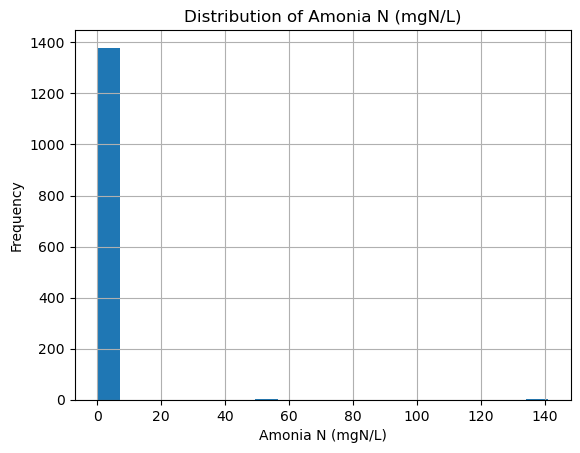

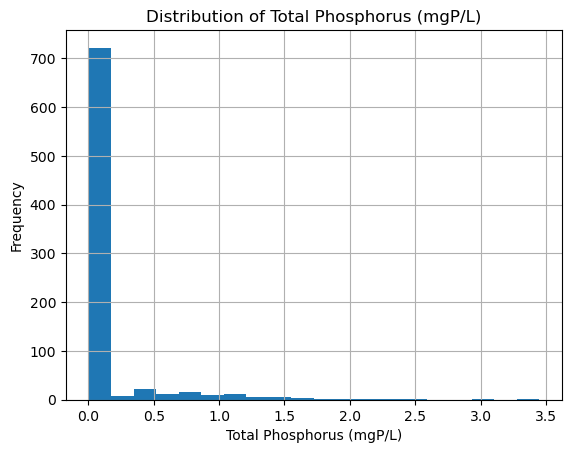

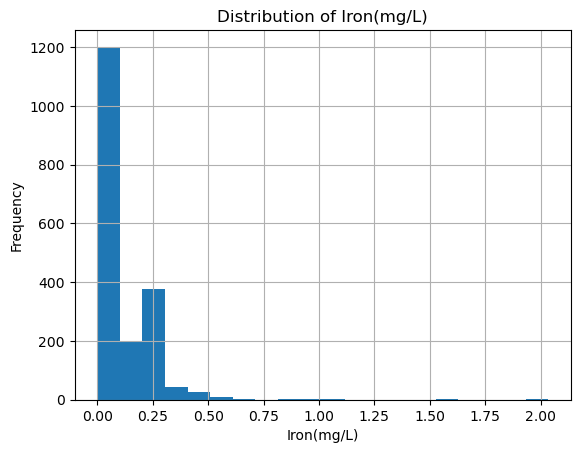

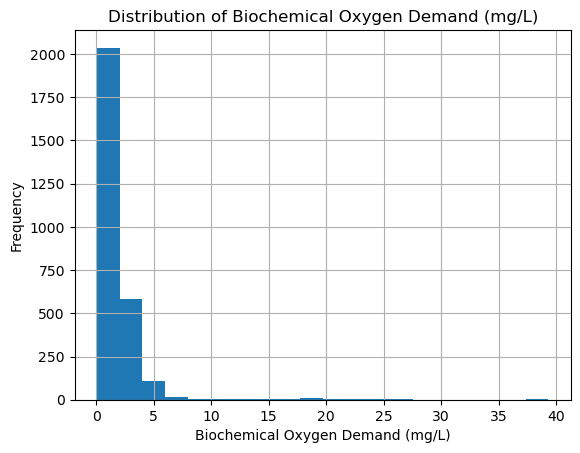

In [33]:
parameters = [
    "Electric Conductivity (μS/cm)",
    "Temperature (ºC)",
    "Dissolved oxygen (mg/L)",
    "Total Dissolved Solids (mg/L)",
    "Potential of Hydrogen (pH)",
    "Calcium (mg/L)",
    "Magnesium (mg/L)",
    "Sodium (mg/L)",
    "Chloride (mg/L)",
    "Sulphate (mg/L)",
    "Total Alkalinity (mg/L as CaCO3)",
    "Total Hardness (mgCaCO3/L)",
    "Nitrate N (mgN/L)",
    "Amonia N (mgN/L)",
    "Total Phosphorus (mgP/L)",
    "Iron(mg/L)",
    "Biochemical Oxygen Demand (mg/L)"
]

for parameter in parameters:
    merged_2[parameter].hist(bins=20)
    plt.title(f"Distribution of {parameter}")
    plt.xlabel(parameter)
    plt.ylabel("Frequency")
    plt.show()

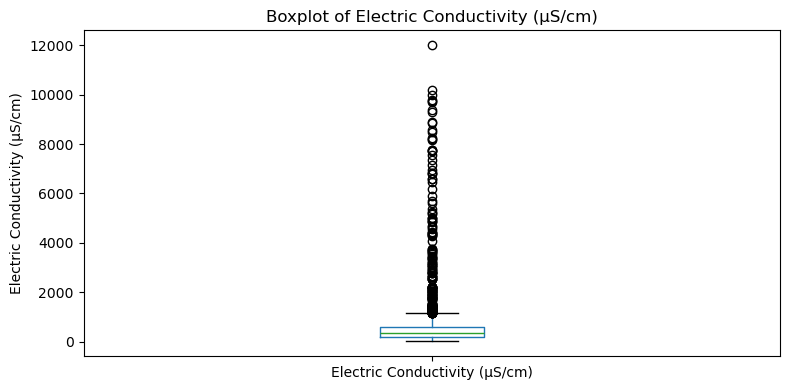

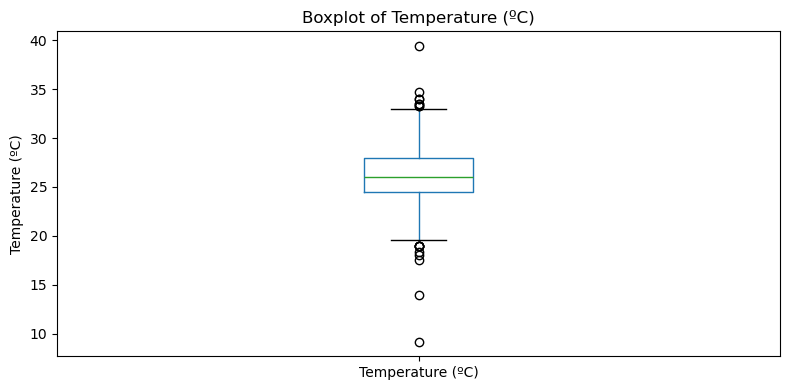

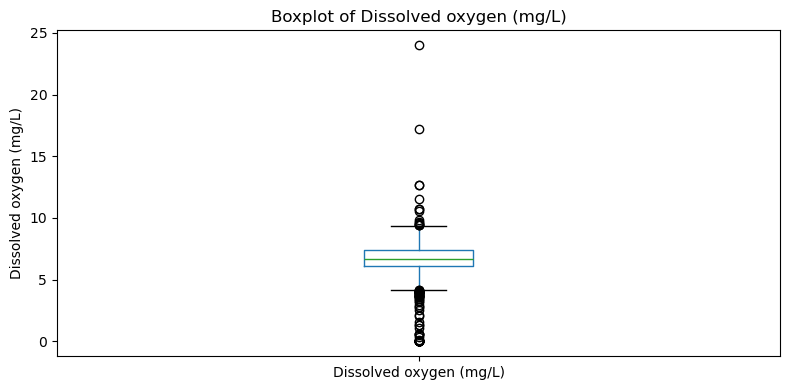

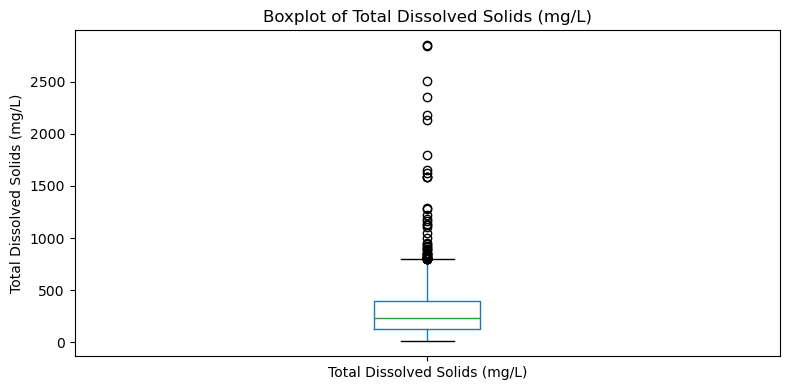

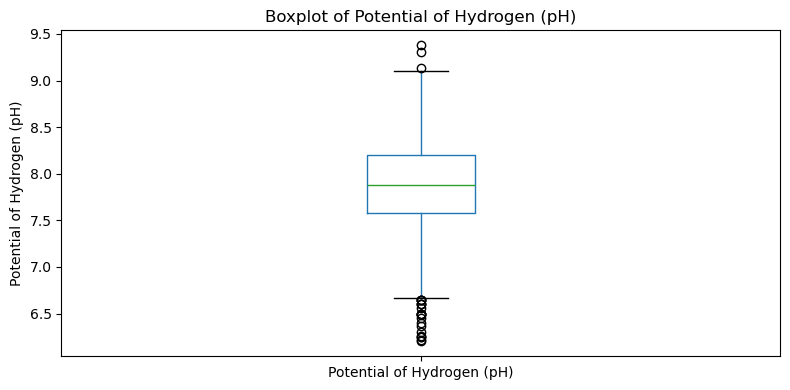

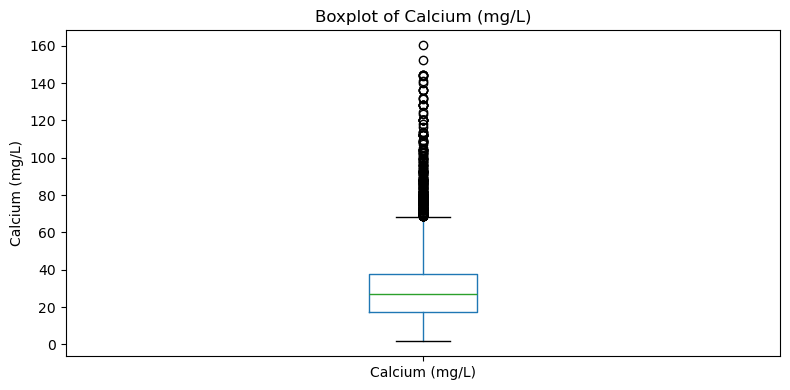

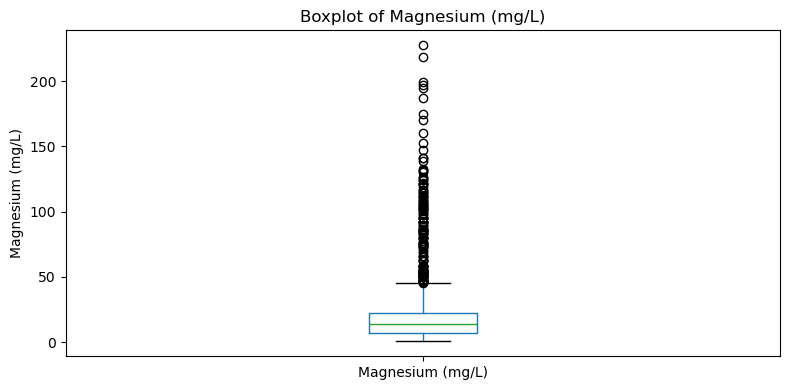

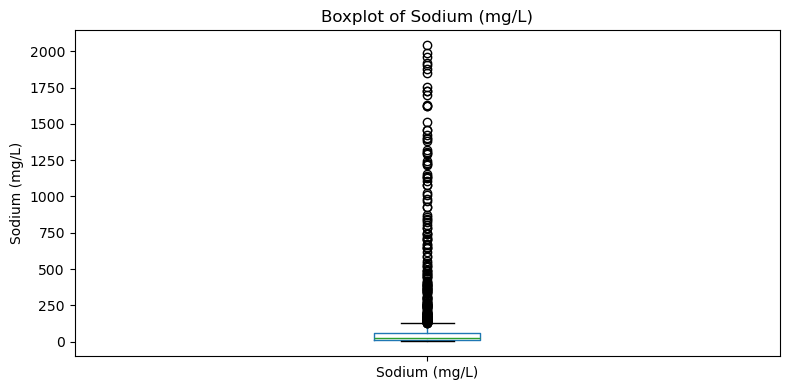

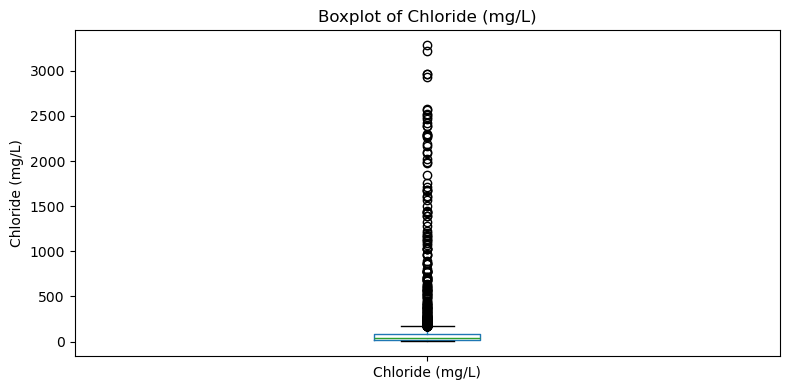

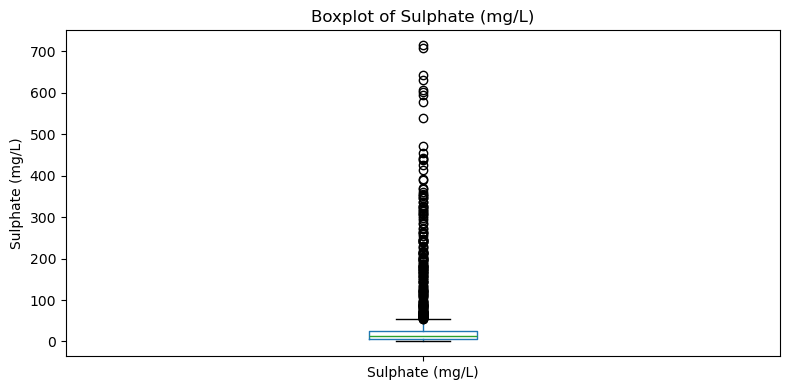

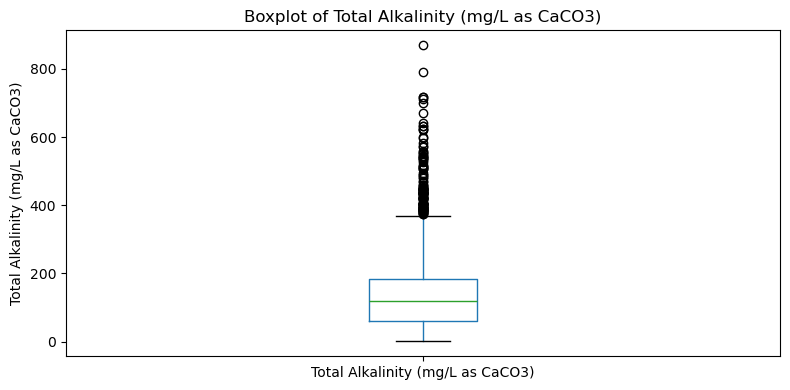

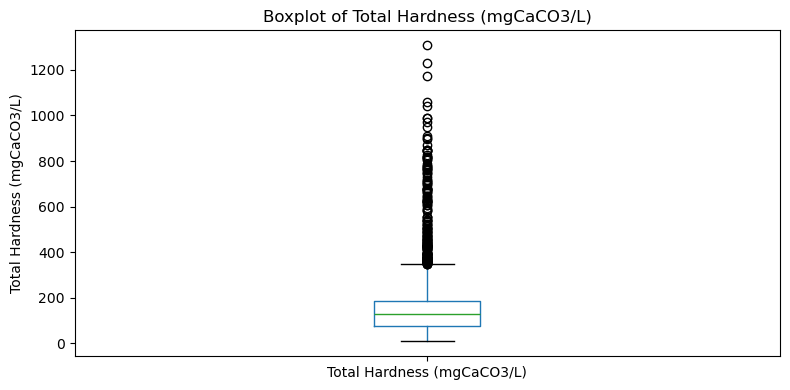

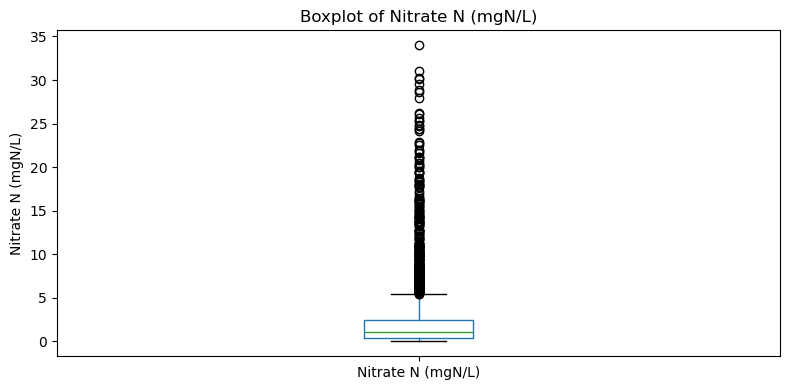

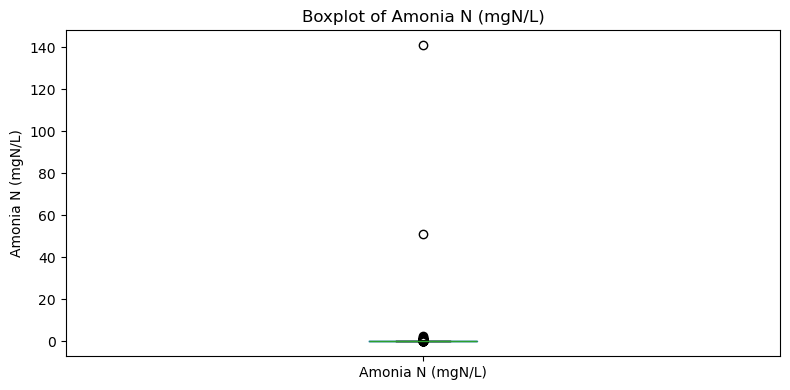

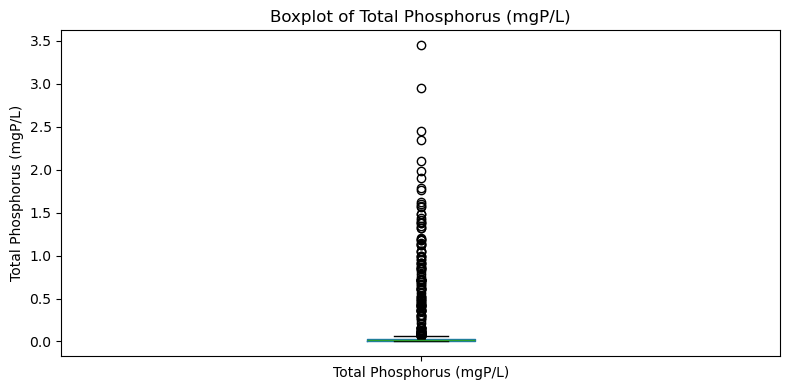

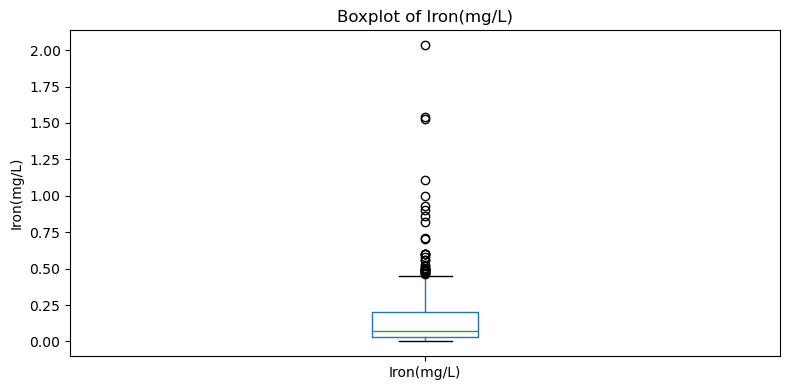

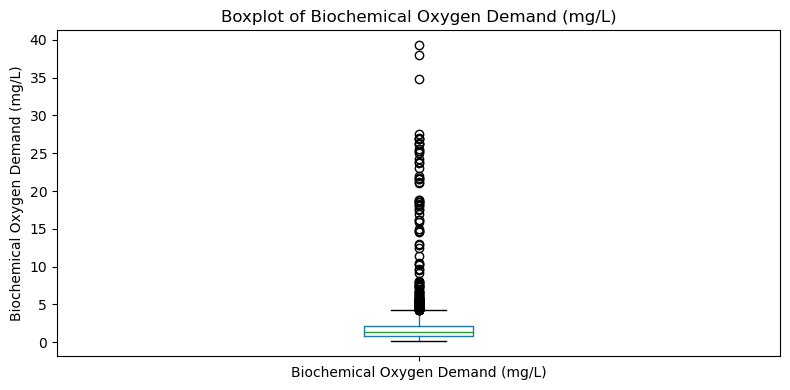

In [34]:
parameters = [
    "Electric Conductivity (μS/cm)",
    "Temperature (ºC)",
    "Dissolved oxygen (mg/L)",
    "Total Dissolved Solids (mg/L)",
    "Potential of Hydrogen (pH)",
    "Calcium (mg/L)",
    "Magnesium (mg/L)",
    "Sodium (mg/L)",
    "Chloride (mg/L)",
    "Sulphate (mg/L)",
    "Total Alkalinity (mg/L as CaCO3)",
    "Total Hardness (mgCaCO3/L)",
    "Nitrate N (mgN/L)",
    "Amonia N (mgN/L)",
    "Total Phosphorus (mgP/L)",
    "Iron(mg/L)",
    "Biochemical Oxygen Demand (mg/L)"
]

for parameter in parameters:
    plt.figure(figsize=(8,4))
    merged_2.boxplot(column=parameter)
    plt.title(f"Boxplot of {parameter}")
    plt.ylabel(parameter)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [35]:
merged_2["Nitrate N (mgN/L)"].describe()

Q1 = merged_2["Nitrate N (mgN/L)"].quantile(0.25)
Median = merged_2["Nitrate N (mgN/L)"].median()
Q3 = merged_2["Nitrate N (mgN/L)"].quantile(0.75)

print(f"Q1: {Q1:.2f}")
print(f"Median: {Median:.2f}")
print(f"Q3: {Q3:.2f}")

Q1: 0.42
Median: 1.13
Q3: 2.45


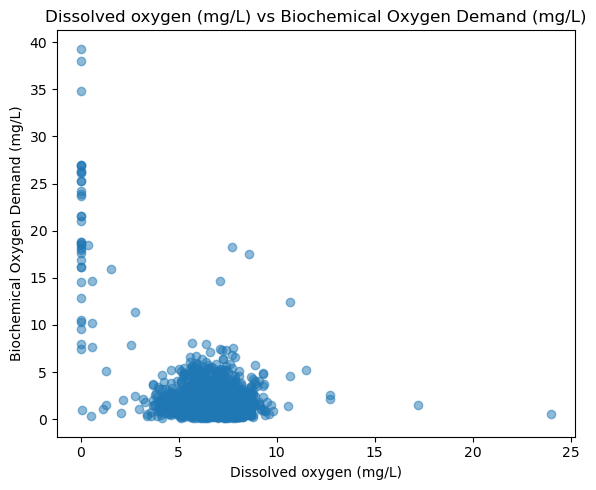

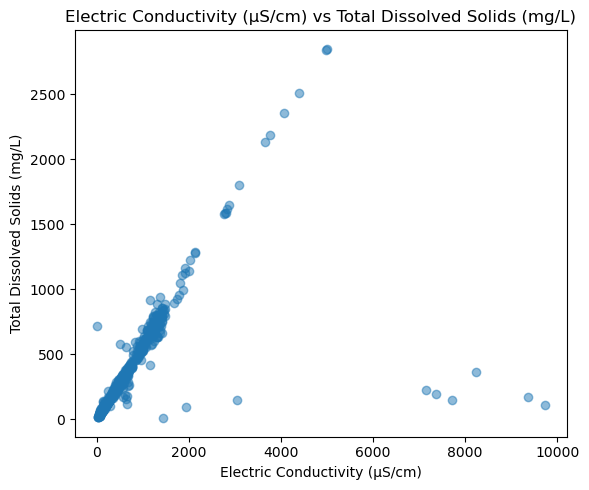

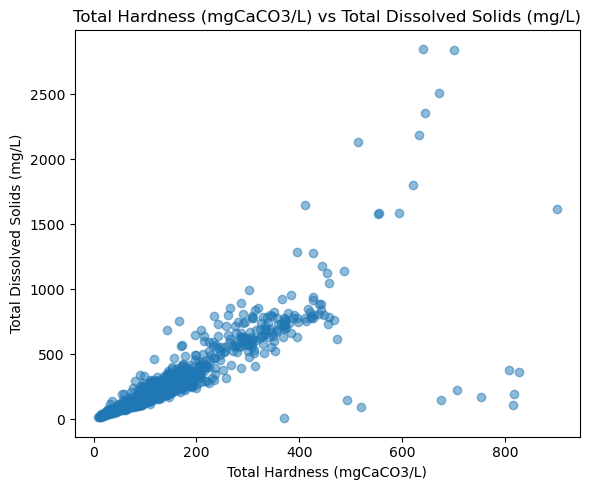

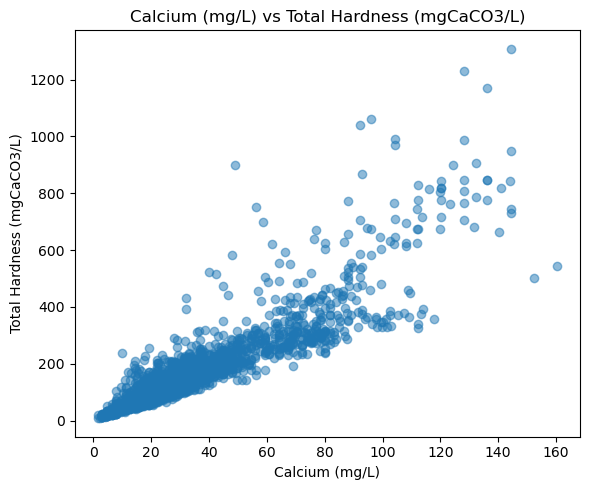

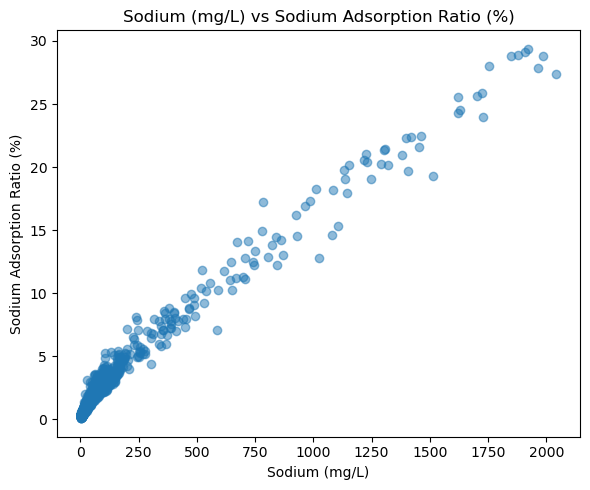

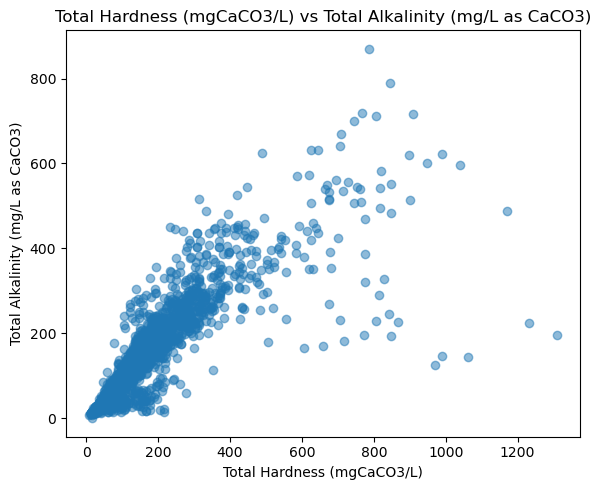

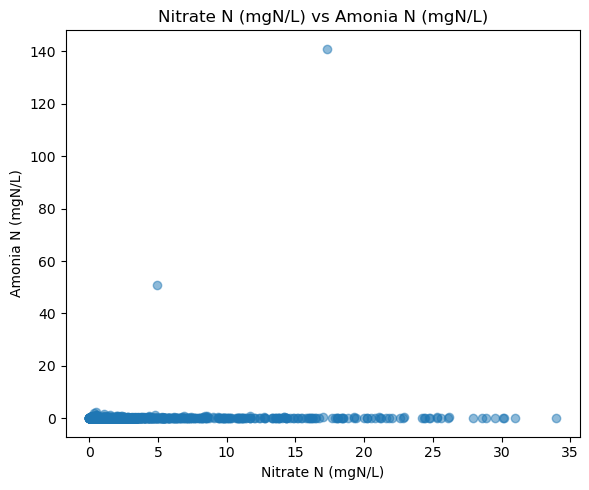

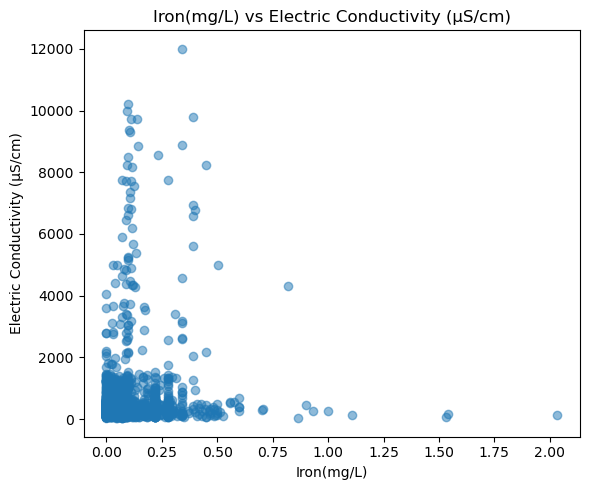

In [36]:
pairs = [
    ("Dissolved oxygen (mg/L)", "Biochemical Oxygen Demand (mg/L)"),
    ("Electric Conductivity (μS/cm)", "Total Dissolved Solids (mg/L)"),
    ("Total Hardness (mgCaCO3/L)", "Total Dissolved Solids (mg/L)"),
    ("Calcium (mg/L)", "Total Hardness (mgCaCO3/L)"),
    ("Sodium (mg/L)", "Sodium Adsorption Ratio (%)"),
    ("Total Hardness (mgCaCO3/L)", "Total Alkalinity (mg/L as CaCO3)"),
    ("Nitrate N (mgN/L)", "Amonia N (mgN/L)"),
    ("Iron(mg/L)", "Electric Conductivity (μS/cm)")
]

for x, y in pairs:
    plt.figure(figsize=(6,5))
    plt.scatter(merged_2[x], merged_2[y], alpha=0.5)
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

In [53]:
parameters = [
    "Electric Conductivity (μS/cm)",
    "Potential of Hydrogen (pH)",
    "Total Dissolved Solids (mg/L)",
    "Dissolved oxygen (mg/L)",
    "Biochemical Oxygen Demand (mg/L)",
    "Total Hardness (mgCaCO3/L)",
    "Total Alkalinity (mg/L as CaCO3)",
    "Nitrate N (mgN/L)",
    "Amonia N (mgN/L)",
    "Iron(mg/L)"
]

river_analysis = (
    merged_2
    .groupby("River")[parameters]
    .mean()
)

river_analysis

,Electric Conductivity (μS/cm),Potential of Hydrogen (pH),Total Dissolved Solids (mg/L),Dissolved oxygen (mg/L),Biochemical Oxygen Demand (mg/L),Total Hardness (mgCaCO3/L),Total Alkalinity (mg/L as CaCO3),Nitrate N (mgN/L),Amonia N (mgN/L),Iron(mg/L)
River,,,,,,,,,,
Bharathapuzha,212.661628,7.749360,116.582857,6.758165,1.187384,91.056304,89.973607,1.116197,0.126022,0.108021
Cauvery,649.820549,7.928080,277.113182,6.853716,1.629445,159.698254,133.988708,2.082038,0.184379,0.117889
Duplicate-Palar,746.974444,7.795667,437.962500,5.739091,1.710856,166.182067,164.417252,0.962186,0.070134,0.058000
Duplicate-Ponnaiyar,996.546646,7.972304,627.376582,5.522169,5.236401,285.090632,273.138026,7.073134,1.065466,0.093178
Duplicate-Vaigai,249.605578,7.769402,88.826087,6.981984,1.418765,97.362816,91.096953,1.865854,0.119865,0.130970
Duplicate-Vellar,408.270833,7.909167,189.975000,5.873333,1.651833,116.409128,114.227675,0.932696,0.039000,0.386500
Tambraparani,2780.000000,7.900000,1585.000000,NaN,0.790000,555.533300,234.614760,4.440000,0.154000,0.000000
Thambraparani,186.794595,7.493081,109.761765,5.800811,1.257892,66.560784,57.844794,1.108215,0.115756,0.121665
Thambraparni,155.000000,7.700000,116.000000,NaN,0.800000,32.416668,34.016390,1.300000,0.600000,1.540000


In [38]:
river_analysis.sort_values(
    by="Biochemical Oxygen Demand (mg/L)",
    ascending=False
)

,Electric Conductivity (μS/cm),Total Dissolved Solids (mg/L),Dissolved oxygen (mg/L),Biochemical Oxygen Demand (mg/L),Total Hardness (mgCaCO3/L),Total Alkalinity (mg/L as CaCO3),Nitrate N (mgN/L),Amonia N (mgN/L),Iron(mg/L)
River,,,,,,,,,
Duplicate-Ponnaiyar,996.546646,627.376582,5.522169,5.236401,285.090632,273.138026,7.073134,1.065466,0.093178
Duplicate-Palar,746.974444,437.962500,5.739091,1.710856,166.182067,164.417252,0.962186,0.070134,0.058000
Duplicate-Vellar,408.270833,189.975000,5.873333,1.651833,116.409128,114.227675,0.932696,0.039000,0.386500
Cauvery,649.820549,277.113182,6.853716,1.629445,159.698254,133.988708,2.082038,0.184379,0.117889
Duplicate-Vaigai,249.605578,88.826087,6.981984,1.418765,97.362816,91.096953,1.865854,0.119865,0.130970
Thambraparani,186.794595,109.761765,5.800811,1.257892,66.560784,57.844794,1.108215,0.115756,0.121665
Bharathapuzha,212.661628,116.582857,6.758165,1.187384,91.056304,89.973607,1.116197,0.126022,0.108021
Thambraparni,155.000000,116.000000,NaN,0.800000,32.416668,34.016390,1.300000,0.600000,1.540000
Tambraparani,2780.000000,1585.000000,NaN,0.790000,555.533300,234.614760,4.440000,0.154000,0.000000


In [39]:
river_analysis.sort_values(
    by="Dissolved oxygen (mg/L)",
    ascending=True
)

,Electric Conductivity (μS/cm),Total Dissolved Solids (mg/L),Dissolved oxygen (mg/L),Biochemical Oxygen Demand (mg/L),Total Hardness (mgCaCO3/L),Total Alkalinity (mg/L as CaCO3),Nitrate N (mgN/L),Amonia N (mgN/L),Iron(mg/L)
River,,,,,,,,,
Duplicate-Ponnaiyar,996.546646,627.376582,5.522169,5.236401,285.090632,273.138026,7.073134,1.065466,0.093178
Duplicate-Palar,746.974444,437.962500,5.739091,1.710856,166.182067,164.417252,0.962186,0.070134,0.058000
Thambraparani,186.794595,109.761765,5.800811,1.257892,66.560784,57.844794,1.108215,0.115756,0.121665
Duplicate-Vellar,408.270833,189.975000,5.873333,1.651833,116.409128,114.227675,0.932696,0.039000,0.386500
Bharathapuzha,212.661628,116.582857,6.758165,1.187384,91.056304,89.973607,1.116197,0.126022,0.108021
Cauvery,649.820549,277.113182,6.853716,1.629445,159.698254,133.988708,2.082038,0.184379,0.117889
Duplicate-Vaigai,249.605578,88.826087,6.981984,1.418765,97.362816,91.096953,1.865854,0.119865,0.130970
Tambraparani,2780.000000,1585.000000,NaN,0.790000,555.533300,234.614760,4.440000,0.154000,0.000000
Thambraparni,155.000000,116.000000,NaN,0.800000,32.416668,34.016390,1.300000,0.600000,1.540000


**Now we will compare important pollutant measuring parameters with their standards**

**lambda could define, and return the defined function/lambda, it works like (func name = lambda [input]: return)**

In [44]:
def highlight_status(value):
    if value == "Exceeds Standard":
        return "background-color: salmon"
    elif value == "Below Standard":
        return "background-color: salmon"
    else:
        return "background-color: lightgreen"

In [45]:
bod_analysis = river_analysis[
    ["Biochemical Oxygen Demand (mg/L)"]
].copy()

bod_analysis["Standard"] = "≤ 3 mg/L"

bod_analysis["Status"] = bod_analysis[
    "Biochemical Oxygen Demand (mg/L)"
].apply(
    lambda x: "Within Standard" if x <= 3 else "Exceeds Standard"
)

bod_analysis.style.map(
    highlight_status,
    subset=["Status"]
)

,Biochemical Oxygen Demand (mg/L),Standard,Status
River,,,
Bharathapuzha,1.187384,≤ 3 mg/L,Within Standard
Cauvery,1.629445,≤ 3 mg/L,Within Standard
Duplicate-Palar,1.710856,≤ 3 mg/L,Within Standard
Duplicate-Ponnaiyar,5.236401,≤ 3 mg/L,Exceeds Standard
Duplicate-Vaigai,1.418765,≤ 3 mg/L,Within Standard
Duplicate-Vellar,1.651833,≤ 3 mg/L,Within Standard
Tambraparani,0.790000,≤ 3 mg/L,Within Standard
Thambraparani,1.257892,≤ 3 mg/L,Within Standard
Thambraparni,0.800000,≤ 3 mg/L,Within Standard


In [46]:
do_analysis = river_analysis[
    ["Dissolved oxygen (mg/L)"]
].copy()

do_analysis["Standard"] = "≥ 5 mg/L"

do_analysis["Status"] = do_analysis[
    "Dissolved oxygen (mg/L)"
].apply(
    lambda x: "Within Standard" if x >= 5 else "Below Standard"
)

do_analysis.style.map(
    highlight_status,
    subset=["Status"]
)

,Dissolved oxygen (mg/L),Standard,Status
River,,,
Bharathapuzha,6.758165,≥ 5 mg/L,Within Standard
Cauvery,6.853716,≥ 5 mg/L,Within Standard
Duplicate-Palar,5.739091,≥ 5 mg/L,Within Standard
Duplicate-Ponnaiyar,5.522169,≥ 5 mg/L,Within Standard
Duplicate-Vaigai,6.981984,≥ 5 mg/L,Within Standard
Duplicate-Vellar,5.873333,≥ 5 mg/L,Within Standard
Tambraparani,nan,≥ 5 mg/L,Below Standard
Thambraparani,5.800811,≥ 5 mg/L,Within Standard
Thambraparni,nan,≥ 5 mg/L,Below Standard


In [54]:
ph_analysis = river_analysis[
    ["Potential of Hydrogen (pH)"]
].copy()

ph_analysis["Standard"] = "6.5 - 8.5"

ph_analysis["Status"] = ph_analysis[
    "Potential of Hydrogen (pH)"
].apply(
    lambda x: "Within Standard"
    if 6.5 <= x <= 8.5
    else "Outside Standard"
)

ph_analysis.style.map(
    highlight_status,
    subset=["Status"]
)

,Potential of Hydrogen (pH),Standard,Status
River,,,
Bharathapuzha,7.749360,6.5 - 8.5,Within Standard
Cauvery,7.928080,6.5 - 8.5,Within Standard
Duplicate-Palar,7.795667,6.5 - 8.5,Within Standard
Duplicate-Ponnaiyar,7.972304,6.5 - 8.5,Within Standard
Duplicate-Vaigai,7.769402,6.5 - 8.5,Within Standard
Duplicate-Vellar,7.909167,6.5 - 8.5,Within Standard
Tambraparani,7.900000,6.5 - 8.5,Within Standard
Thambraparani,7.493081,6.5 - 8.5,Within Standard
Thambraparni,7.700000,6.5 - 8.5,Within Standard


In [50]:
tds_analysis = river_analysis[
    ["Total Dissolved Solids (mg/L)"]
].copy()

tds_analysis["Standard"] = "≤ 500 mg/L"

tds_analysis["Status"] = tds_analysis[
    "Total Dissolved Solids (mg/L)"
].apply(
    lambda x: "Within Standard" if x <= 500 else "Exceeds Standard"
)

tds_analysis.style.map(
    highlight_status,
    subset=["Status"]
)

,Total Dissolved Solids (mg/L),Standard,Status
River,,,
Bharathapuzha,116.582857,≤ 500 mg/L,Within Standard
Cauvery,277.113182,≤ 500 mg/L,Within Standard
Duplicate-Palar,437.962500,≤ 500 mg/L,Within Standard
Duplicate-Ponnaiyar,627.376582,≤ 500 mg/L,Exceeds Standard
Duplicate-Vaigai,88.826087,≤ 500 mg/L,Within Standard
Duplicate-Vellar,189.975000,≤ 500 mg/L,Within Standard
Tambraparani,1585.000000,≤ 500 mg/L,Exceeds Standard
Thambraparani,109.761765,≤ 500 mg/L,Within Standard
Thambraparni,116.000000,≤ 500 mg/L,Within Standard


In [51]:
ec_analysis = river_analysis[
    ["Electric Conductivity (μS/cm)"]
].copy()

ec_analysis["Standard"] = "≤ 1500 μS/cm"

ec_analysis["Status"] = ec_analysis[
    "Electric Conductivity (μS/cm)"
].apply(
    lambda x: "Within Standard" if x <= 1500 else "Exceeds Standard"
)

ec_analysis.style.map(
    highlight_status,
    subset=["Status"]
)

,Electric Conductivity (μS/cm),Standard,Status
River,,,
Bharathapuzha,212.661628,≤ 1500 μS/cm,Within Standard
Cauvery,649.820549,≤ 1500 μS/cm,Within Standard
Duplicate-Palar,746.974444,≤ 1500 μS/cm,Within Standard
Duplicate-Ponnaiyar,996.546646,≤ 1500 μS/cm,Within Standard
Duplicate-Vaigai,249.605578,≤ 1500 μS/cm,Within Standard
Duplicate-Vellar,408.270833,≤ 1500 μS/cm,Within Standard
Tambraparani,2780.000000,≤ 1500 μS/cm,Exceeds Standard
Thambraparani,186.794595,≤ 1500 μS/cm,Within Standard
Thambraparni,155.000000,≤ 1500 μS/cm,Within Standard


In [52]:
iron_analysis = river_analysis[
    ["Iron(mg/L)"]
].copy()

iron_analysis["Standard"] = "≤ 0.3 mg/L"

iron_analysis["Status"] = iron_analysis[
    "Iron(mg/L)"
].apply(
    lambda x: "Within Standard" if x <= 0.3 else "Exceeds Standard"
)

iron_analysis.style.map(
    highlight_status,
    subset=["Status"]
)

,Iron(mg/L),Standard,Status
River,,,
Bharathapuzha,0.108021,≤ 0.3 mg/L,Within Standard
Cauvery,0.117889,≤ 0.3 mg/L,Within Standard
Duplicate-Palar,0.058000,≤ 0.3 mg/L,Within Standard
Duplicate-Ponnaiyar,0.093178,≤ 0.3 mg/L,Within Standard
Duplicate-Vaigai,0.130970,≤ 0.3 mg/L,Within Standard
Duplicate-Vellar,0.386500,≤ 0.3 mg/L,Exceeds Standard
Tambraparani,0.000000,≤ 0.3 mg/L,Within Standard
Thambraparani,0.121665,≤ 0.3 mg/L,Within Standard
Thambraparni,1.540000,≤ 0.3 mg/L,Exceeds Standard


**BOD: CPCB Class C standard (≤ 3 mg/L).
DO: CPCB Class C standard (≥ 5 mg/L).
pH: CPCB Class C standard (6.5–8.5).
Iron: BIS IS 10500 drinking water standard (≤ 0.3 mg/L).
TDS: BIS IS 10500 drinking water standard (≤ 500 mg/L acceptable limit).
EC: State clearly that you are using a commonly accepted guideline because CPCB's designated best-use criteria do not specify an EC limit.**

** we use .isna(x) it tell if x is missing it will return 0**

In [56]:
river_score = river_analysis.copy()

river_score["BOD Score"] = river_score["Biochemical Oxygen Demand (mg/L)"].apply(
    lambda x: 0 if pd.isna(x) else (1 if x <= 3 else -1)
)
river_score["DO Score"] = river_score["Dissolved oxygen (mg/L)"].apply(
    lambda x: 0 if pd.isna(x) else (1 if x >= 5 else -1)
)
river_score["TDS Score"] = river_score["Total Dissolved Solids (mg/L)"].apply(
    lambda x: 0 if pd.isna(x) else (1 if x <= 500 else -1)
)
river_score["EC Score"] = river_score["Electric Conductivity (μS/cm)"].apply(
    lambda x: 0 if pd.isna(x) else (1 if x <= 1500 else -1)
)
river_score["Iron Score"] = river_score["Iron(mg/L)"].apply(
    lambda x: 0 if pd.isna(x) else (1 if x <= 0.3 else -1)
)
river_score["pH Score"] = river_score["Potential of Hydrogen (pH)"].apply(
    lambda x: 0 if pd.isna(x) else (1 if 6.5 <= x <= 8.5 else -1)
)

In [57]:
score_columns = [
    "BOD Score",
    "DO Score",
    "TDS Score",
    "EC Score",
    "Iron Score",
    "pH Score"
]
river_score["Overall Score"] = river_score[score_columns].sum(axis=1)

**.sum() will give sum of axis, by default it is axis=0, which means vertical/column wise, and axis=1 will give addition of horizontal/row wise**

In [58]:
river_score = river_score.sort_values(
    by="Overall Score",
    ascending=False
)

In [64]:
def highlight_parameters(value, column):

    if pd.isna(value):
        return "background-color: lightgray"

    if column == "Biochemical Oxygen Demand (mg/L)":
        return "background-color: lightgreen" if value <= 3 else "background-color: salmon"

    elif column == "Dissolved oxygen (mg/L)":
        return "background-color: lightgreen" if value >= 5 else "background-color: salmon"

    elif column == "Total Dissolved Solids (mg/L)":
        return "background-color: lightgreen" if value <= 500 else "background-color: salmon"

    elif column == "Electric Conductivity (μS/cm)":
        return "background-color: lightgreen" if value <= 1500 else "background-color: salmon"

    elif column == "Iron(mg/L)":
        return "background-color: lightgreen" if value <= 0.3 else "background-color: salmon"

    elif column == "pH":
        return "background-color: lightgreen" if 6.5 <= value <= 8.5 else "background-color: salmon"

    return ""

In [63]:
styled_table = final_ranking.style.apply(
    lambda col: [highlight_parameters(v, col.name) for v in col],
    axis=0
)

styled_table

,Biochemical Oxygen Demand (mg/L),Dissolved oxygen (mg/L),Total Dissolved Solids (mg/L),Electric Conductivity (μS/cm),Iron(mg/L),Potential of Hydrogen (pH),Overall Score
River,,,,,,,
Bharathapuzha,1.187384,6.758165,116.582857,212.661628,0.108021,7.749360,6
Cauvery,1.629445,6.853716,277.113182,649.820549,0.117889,7.928080,6
Duplicate-Palar,1.710856,5.739091,437.962500,746.974444,0.058000,7.795667,6
Duplicate-Vaigai,1.418765,6.981984,88.826087,249.605578,0.130970,7.769402,6
Thambraparani,1.257892,5.800811,109.761765,186.794595,0.121665,7.493081,6
Duplicate-Vellar,1.651833,5.873333,189.975000,408.270833,0.386500,7.909167,4
Thambraparni,0.800000,nan,116.000000,155.000000,1.540000,7.700000,3
Duplicate-Ponnaiyar,5.236401,5.522169,627.376582,996.546646,0.093178,7.972304,2
Tambraparani,0.790000,nan,1585.000000,2780.000000,0.000000,7.900000,1


<Axes: title={'center': 'Overall River Water Quality Score'}, ylabel='River'>

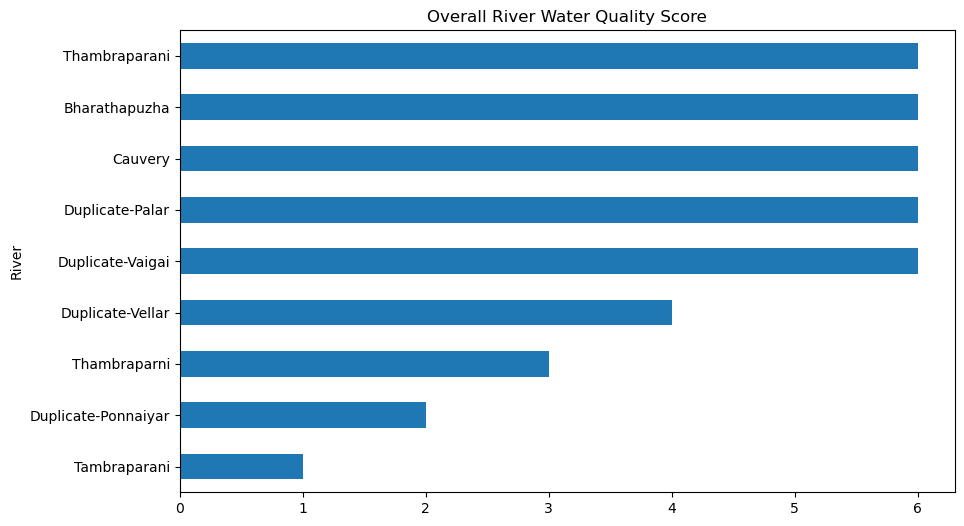

In [65]:
river_score["Overall Score"].sort_values().plot(
    kind="barh",
    figsize=(10,6),
    title="Overall River Water Quality Score"
)

**Bharathapuzha, Cauvery, Duplicate-Palar, Duplicate-Vaigai, and Thambraparani satisfied all evaluated water quality criteria, achieving the highest overall score.
Duplicate-Vellar met most standards but exceeded the iron limit.
Duplicate-Ponnaiyar showed elevated BOD and TDS values, reducing its overall score.
Tambraparani exhibited very high TDS and electrical conductivity, indicating elevated dissolved salts despite acceptable BOD, iron, and pH.
Missing dissolved oxygen values reduced the confidence of assessment for some rivers.**

<Axes: xlabel='River'>

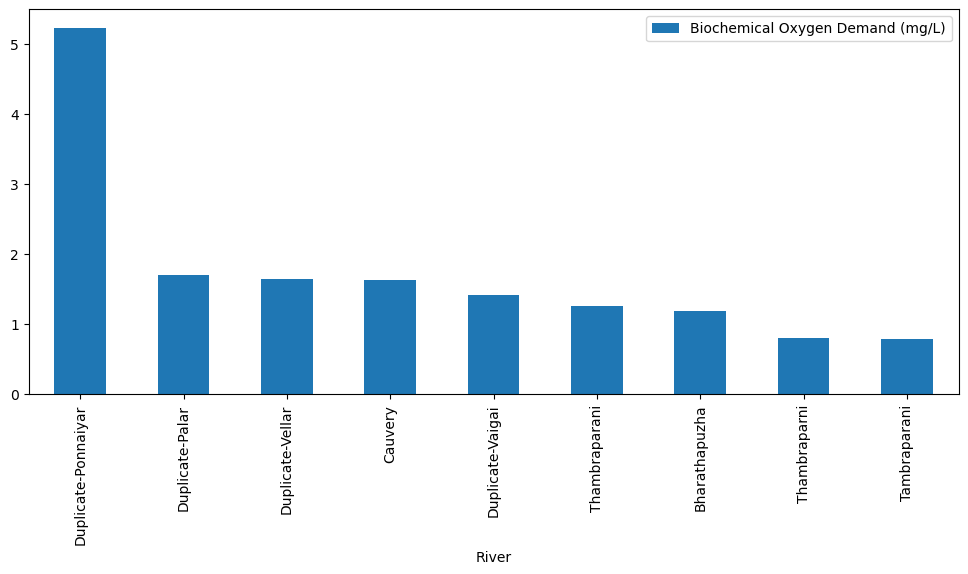

In [66]:
river_analysis.sort_values(
    "Biochemical Oxygen Demand (mg/L)",
    ascending=False
).plot.bar(
    y="Biochemical Oxygen Demand (mg/L)",
    figsize=(12,5)
)

In [67]:
river_score.to_csv("River_Water_Quality_Final.csv")